In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_rows

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [64]:
from neuralprophet import NeuralProphet
import pandas as pd

df = diamonds = sns.load_dataset('diamonds')

m = NeuralProphet()

metrics = m.fit(df, freq="D")

forecast = m.predict(df)

diamonds.head()

ModuleNotFoundError: No module named 'neuralprophet'

In [ ]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
# baseline model
X = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state = 42
                                                   )

model = LinearRegression()
model = model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
y_estimated = model.predict(X_train)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(model.coef_)

Train r2 = 0.8592729084866024
Test r2 = 0.8589542625888917
MAE_test = 888.4808633901818
RMSE_test = 1497.390698543849
MAE_train = 891.8081818770223
RMSE_train = 1496.7760457375086
[10683.18425966  -204.09955335  -104.26736872 -1286.79957429
    37.63252069    53.39486424]


Evaluation metrics - train and test R squared are almost identical, so no obvious overfitting. The model is capturing about 86% of the variance on unseen data


In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cross_val_results(X, y, model = LinearRegression(), cv=kf, scoring = 'r2'):
    scores = cross_val_score(model, X, y, cv=5, scoring = 'r2')

    print(f"Scores: {scores}")
    print(f"Mean: {scores.mean()}")
    print(f"Std: {scores.std()}")

In [ ]:
cross_val_results(X, y)

Scores: [  0.34224026   0.70010775   0.83186637 -14.25049522  -0.86365774]
Mean: -2.647987716317524
Std: 5.832025459382884


Validation results tell a different story. It seems as though cross validation splits the data quite differently, and outliers that end up in the validation fold can ruin the R squared result. So our model isn't doing a bad job, the data is just fragile.

# Feature engineering

## Categorical variables

Next we can look at improving the model, using feature engineering, where we will create some new predictors for the model. For example, in the diamonds dataset there were some columns we didn't use. So far we have just used the numerical columns: depth, table, price, x, y and z. But what about the categorical columns - cut, colour, clarity? These variables will also influence the price in some way. 

We need to convert these columns to numbers for our model to understand, as it doesn't understand categories.

In [ ]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
diamonds['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

How could we convert these to numerical values? We could create some sort of rating, where "Ideal" is 0 and "Fair" is 4, but this wouldn't work for a column where we don't know the context of the categories, for example the `color` column.

A method we can use in this case is the use of dummy columns, and we can convert these categories into separate columns. In the image below, we have some names and dummy indicator columns are created based on these names. A 1 will be present where the name is present, and a 0 will be present when the name is absent.

### Dummy columns(One-Hot Encoding)

https://datascienceparichay.com/article/pandas-get-dummies-function/

"The pandas get_dummies() function is used to convert a categorical variable to indicator/dummy variables (columns). It returns the dummy coded data as a pandas dataframe."

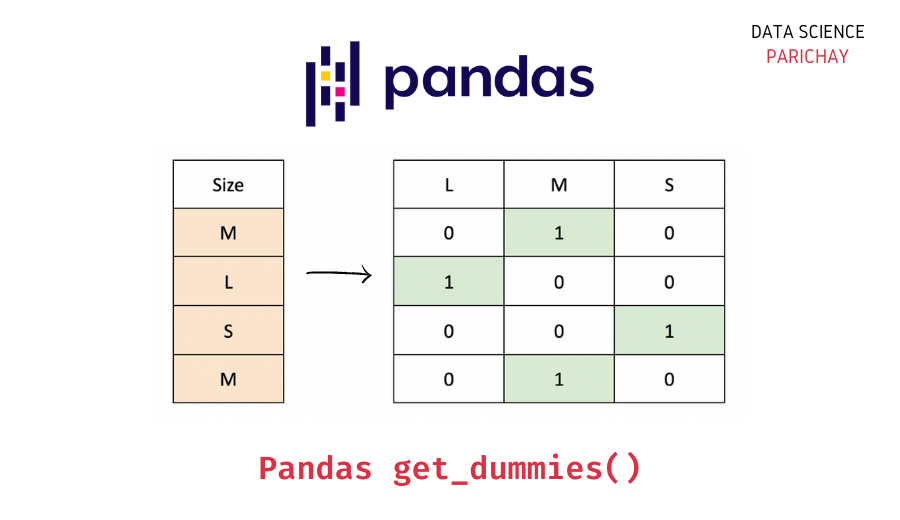

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

The default output is boolean, if we want the output to be a 0 or a 1 we need to specify `dtype = int`

In [ ]:
dummies_cut = pd.get_dummies(diamonds['cut'], dtype=int, drop_first = True)
dummies_cut.head()

,Premium,Very Good,Good,Fair
0,0,0,0,0
1,1,0,0,0
2,0,0,1,0
3,1,0,0,0
4,0,0,1,0


In [ ]:
diamonds_dummies = pd.concat([diamonds, dummies_cut], axis = 1)
diamonds_dummies.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,Premium,Very Good,Good,Fair
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0,0,0,0
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,1,0,0,0
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0,0,1,0
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,1,0,0,0
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0,0,1,0


We have created a problem for ourselves though, in the sense that in the model there will be a perfect correlation (multicollinearity). The model will know that each of these categories compensate each other; for example, if a diamond isn't premium, very good, good or fair it will be ideal - they are dependent of each other. 

To try and combat this we can introduce `drop_first = True` which will drop the first column from the data frame. For example, the `Ideal` column will be dropped and this means the model won't have the full picture of the data as it breaks the relationship between the variables.

In [ ]:
dummies_color_clarity = pd.get_dummies(diamonds[['cut', 'color', 'clarity']], dtype=int, drop_first = True)
dummies_color_clarity.head()

,cut_Premium,cut_Very Good,cut_Good,cut_Fair,color_E,color_F,color_G,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0


We now have 17 columns, and notice that we are missing one column from each categorical variable: Ideal from `cut`, D from `color`, and IF from `clarity`. Now we need to link or concatenate this dataframe with the original dataframe. We will use `axis=1` to concatenate the dataframe to the column rather than to the rows.

In [ ]:
diamonds_dummies = pd.concat([diamonds, dummies_color_clarity], axis = 1)
diamonds_dummies.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,...,0,0,0,0,0,0,0,0,1,0
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,...,0,0,0,0,0,0,0,1,0,0
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,...,0,0,0,0,0,1,0,0,0,0
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,...,0,1,0,0,0,0,1,0,0,0
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,...,0,0,1,0,0,0,0,0,1,0


In [ ]:
X = diamonds_dummies.drop(columns = ['cut', 'color', 'clarity', 'price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

model = LinearRegression()
model = model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
y_estimated = model.predict(X_train)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(model.coef_)

Train r2 = 0.919994314909212
Test r2 = 0.9189331350419372
MAE_test = 737.1513665933421
RMSE_test = 1135.2116445190734
MAE_train = 742.2563516523846
RMSE_train = 1128.5697163572002
[ 1.12807843e+04 -6.50910151e+01 -2.66000210e+01 -1.00804160e+03
 -3.52845036e+00 -3.64633703e+01 -7.68877685e+01 -1.08863766e+02
 -2.67018777e+02 -8.58815946e+02 -2.18198603e+02 -2.79716403e+02
 -4.95581527e+02 -9.99086408e+02 -1.47958447e+03 -2.37201983e+03
 -3.50651680e+02 -4.07733147e+02 -7.86039055e+02 -1.10232896e+03
 -1.69053004e+03 -2.66450463e+03 -5.36594460e+03]


In [ ]:
cross_val_results(X, y)

Scores: [  0.34224026   0.70010775   0.83186637 -14.25049522  -0.86365774]
Mean: -2.647987716317524
Std: 5.832025459382884


Excellent results with lower errors. Still have some instability though.

## Feature scaling

Feature scaling is another very important factor. Let's look at the histogram of the carat column to view the distribution of values.

<Axes: xlabel='carat', ylabel='Count'>

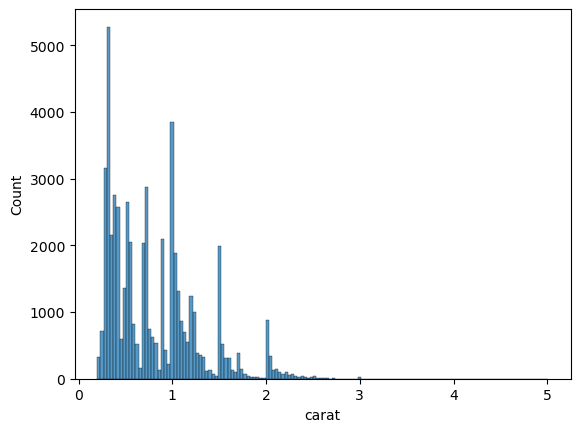

In [ ]:
sns.histplot(diamonds['carat'])

We have a range of carat values from 0 to 5 - although only 0 to 3 show up on the histogram, there are bound to be a few outliers. Now we will look at the range for depth.

<Axes: xlabel='depth', ylabel='Count'>

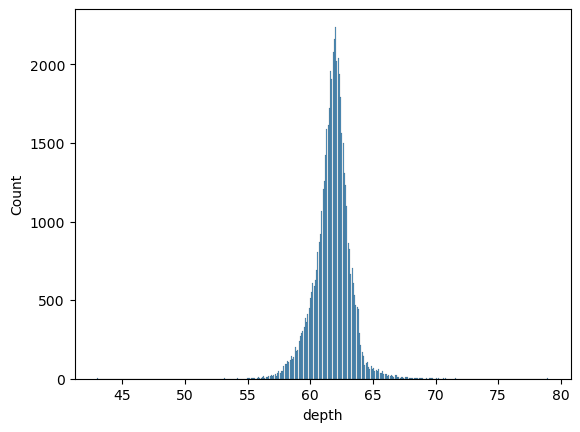

In [ ]:
sns.histplot(diamonds['depth'])

This time we are measuring in mm, and the range is from roughly 45 mm to 80 mm. If we superimpose the two histograms, we can see the following:

<Axes: xlabel='carat', ylabel='Count'>

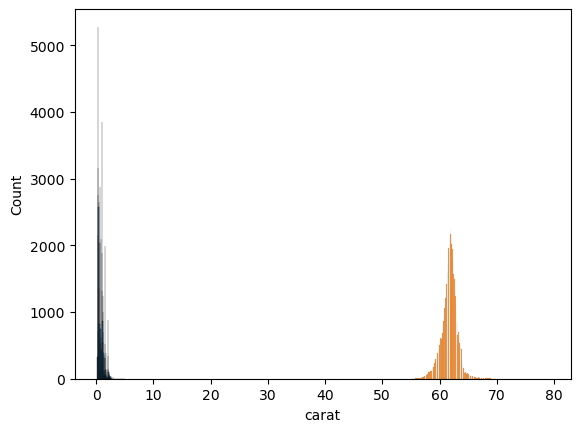

In [ ]:
sns.histplot(diamonds['carat'])
sns.histplot(diamonds['depth'])

These values aren't overlapping on the histogram, because the metrics we are using are completely different. The model will take into account these different units and it will think that depth has a higher importance than carat just because the values are higher.

When we use a "normal" linear regression we don't **have** to use feature scaling but when using ridge and lasso this is something we will need to take into consideration as they are very sensitive to the magnitude of the predictors. Scaling involves putting all of the predictors on one scale and there are a few different methods to do this.

### MinMaxScalar

Min-max scaling is a scaling technique in which values are shifted and rescaled so that they range between 0 and 1.

https://stackoverflow.com/questions/62178888/can-someone-explain-to-me-how-minmaxscaler-works

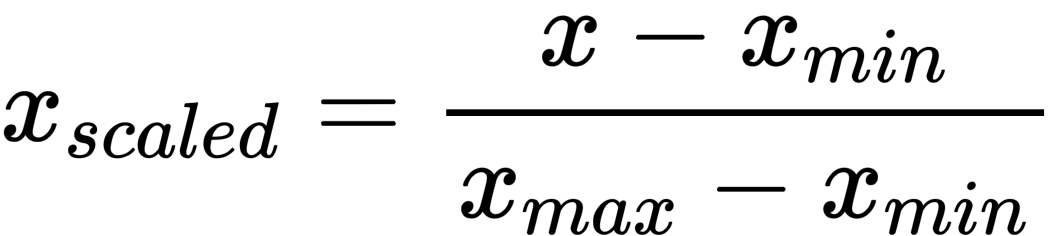

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# fit scaler on training data
norm = MinMaxScaler().fit(X)

# transform training data
X_norm= norm.transform(X)


Now, we can see that all the values for `X_train_norm` and `X_test_norm` are all between 0 and 1.

In [ ]:
X_norm

array([[0.00623701, 0.51388889, 0.23076923, ..., 0.        , 1.        ,
        0.        ],
       [0.002079  , 0.46666667, 0.34615385, ..., 1.        , 0.        ,
        0.        ],
       [0.00623701, 0.38611111, 0.42307692, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.1039501 , 0.55      , 0.32692308, ..., 1.        , 0.        ,
        0.        ],
       [0.13721414, 0.5       , 0.28846154, ..., 0.        , 1.        ,
        0.        ],
       [0.11434511, 0.53333333, 0.23076923, ..., 0.        , 1.        ,
        0.        ]])

We can then use this scaled data in the Lasso Model. Sometimes it might improve the model but other times it doesn't really have an effect on it. If it doesn't have much of an effect, then it's better to use the original data as the coefficients will be more relevant, but if it has a good effect on the model then it would be better to use the normalised data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state = 42)

In [ ]:
lasso_model = Lasso(alpha=30) # use Lasso model - penalises magnitude of coefficients. alpha = 30 is "Large", so penalises relatively agressively
lasso_model.fit(X_train, y_train)

y_predicted = lasso_model.predict(X_test)
y_estimated = lasso_model.predict(X_train)

print('Train r2 =', lasso_model.score(X_train, y_train))
print('Test r2 =', lasso_model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(lasso_model.coef_)

Train r2 = 0.8859860064373404
Test r2 = 0.8873077606393308
MAE_test = 812.3168917246848
RMSE_test = 1338.450002076719
MAE_train = 820.5929440665116
RMSE_train = 1347.2464476388452
[36522.48254629    -0.            -0.             0.
     0.             0.             0.            -0.
    -0.           -62.1778422      0.             0.
     0.          -176.88701063  -369.60883571  -882.17887655
    44.67109289   200.92151876     0.            -0.
  -509.11124453 -1130.62394867 -1766.03189954]


In [ ]:
cross_val_results(X_norm, y, model = Lasso(alpha=30), cv=5, scoring = 'r2')

Scores: [ 0.09695315  0.65276749  0.4859367  -2.37375964 -0.95794901]
Mean: -0.41921026060833294
Std: 1.1265304890453418


R squared performance has dropped slightly (to be expected). Many coefficients have shrunk to 0 (Lasso model decided to remove them due to not contributing much/causing instability/highly correlated with other predictors).

Validation score has slightly improved, so the model has a slightly worse fit but is more robust

### Standardization

Standardisation is another scaling technique where the values are centred around the mean with a unit standard deviation. This means that the mean of the attribute becomes zero and the resultant distribution has a unit standard deviation.

This will standardise the values to be between -3 and +3, although if very large outliers were present this may change to -6 and +6.

https://blog.alliedoffsets.com/standardization-the-secret-to-better-data-science

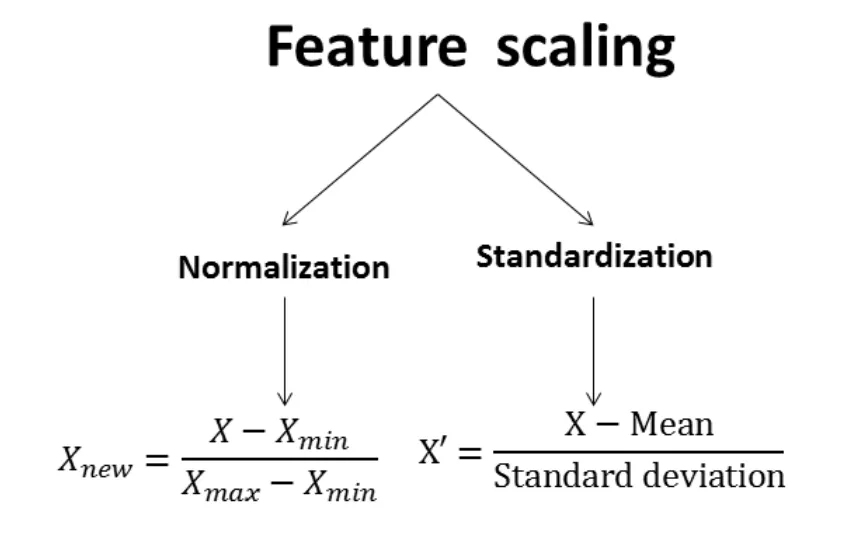

https://quantra.quantinsti.com/glossary/Standard-Normal-Distribution

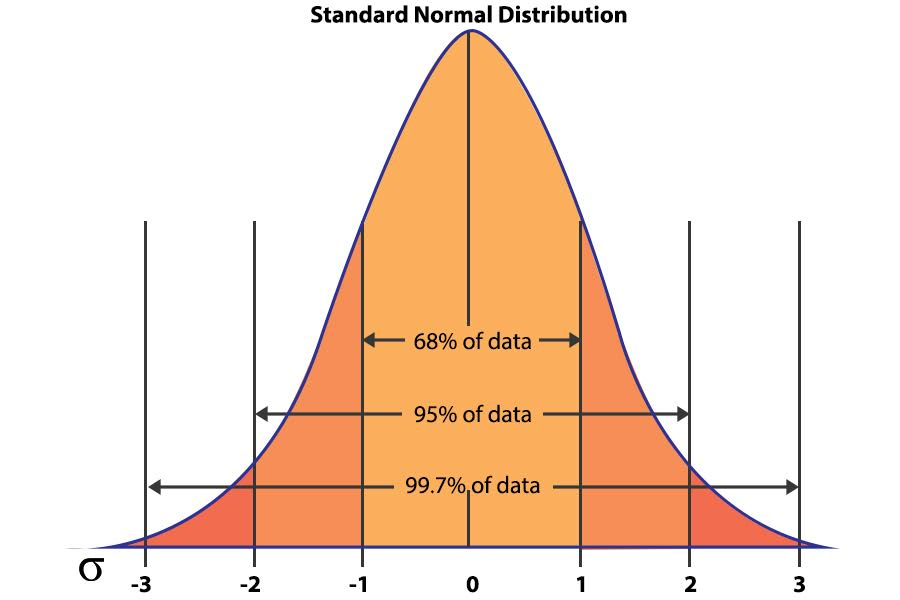

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Create a StandardScaler object and fit it to X
# This calculates the mean and standard deviation for each feature
stand_scale = StandardScaler().fit(X)

# Apply the standardisation to X
# Each feature is transformed to have mean 0 and standard deviation 1
X_stand = stand_scale.transform(X)


In [ ]:
X_stand

array([[-1.19816781, -0.17409151, -1.09967199, ..., -0.56536097,
         2.2060983 , -0.11802048],
       [-1.24036129, -1.36073849,  1.58552871, ...,  1.76878145,
        -0.45328896, -0.11802048],
       [-1.19816781, -3.38501862,  3.37566251, ..., -0.56536097,
        -0.45328896, -0.11802048],
       ...,
       [-0.20662095,  0.73334442,  1.13799526, ...,  1.76878145,
        -0.45328896, -0.11802048],
       [ 0.13092691, -0.52310533,  0.24292836, ..., -0.56536097,
         2.2060983 , -0.11802048],
       [-0.10113725,  0.31452784, -1.09967199, ..., -0.56536097,
         2.2060983 , -0.11802048]])

In [ ]:
X_train_stand, X_test_stand, y_train_stand, y_test_stand = train_test_split(X_stand, y, test_size=0.2, random_state = 42)

In [ ]:
lasso_model = Lasso(alpha=30) # use Lasso model - penalises magnitude of coefficients. alpha = 30 is "Large", so penalises relatively agressively
lasso_model.fit(X_train_stand, y_train_stand)

y_predicted = lasso_model.predict(X_test_stand)
y_estimated = lasso_model.predict(X_train_stand)

print('Train r2 =', lasso_model.score(X_train_stand, y_train_stand))
print('Test r2 =', lasso_model.score(X_test_stand, y_test_stand))

print('MAE_test =', mean_absolute_error(y_test_stand, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test_stand, y_predicted))

print('MAE_train =', mean_absolute_error(y_train_stand, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train_stand, y_estimated))

Train r2 = 0.912784502226466
Test r2 = 0.9128818199354891
MAE_test = 788.9659255429846
RMSE_test = 1176.8186579266219
MAE_train = 793.3312189965525
RMSE_train = 1178.324207924512


In [ ]:
cross_val_results(X_stand, y, model = Lasso(alpha=30), cv=5, scoring = 'r2')

Scores: [ 0.18649588  0.68403801  0.79296178 -8.89904338 -1.00755927]
Mean: -1.648621395456764
Std: 3.6810287507150727


# Target transformation

Linear regression likes targets that follow the normal distribution (bell curve). Here we can see this is not the case. But how do we deal with this?

<Axes: xlabel='price', ylabel='Count'>

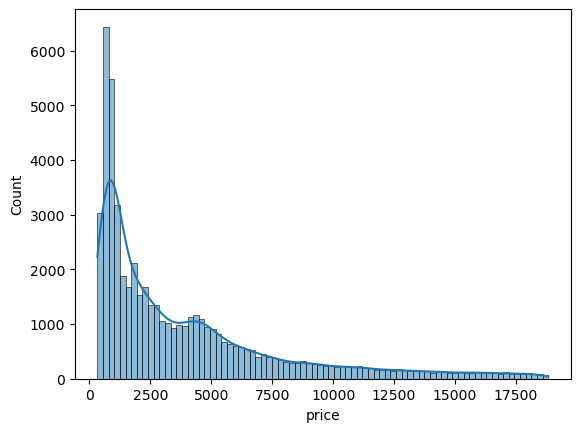

In [ ]:
sns.histplot(diamonds['price'], kde = True)

Something we haven't yet taken into consideration is the relationship between the target variable and the predictors might be wrong. For example, we might need to change the predictor to the log of the predictor, or the square root, etc. It can be common for there to be a logatrithmic relationship between the target variable and other predictors, so we can use a function called BoxCox. This function has a parameter, lambda, which will allow us to transform the target. 

boxcox(data, lambda)

Some common values for lambda:

- lambda = -1. is a reciprocal transformation. It transforms each datapoint to its reciprocal $\frac{1}{x}$.
- lambda = -0.5 is a reciprocal square root transformation. It transforms each datapoint to the reciprocal of its square root $ \frac{1}{\sqrt{x}} $
- lambda = 0.0 is a log transformation, which applies the natural logarithm to each data point
- lambda = 0.5 is a square root transformation which transforms each data point to its square root $\sqrt{x}$
- lambda = 1.0 is no transformation and leaves the data unchanged.

In [ ]:
from scipy.stats import boxcox

https://goldinlocks.github.io/Data-distributions-transformations/

Box-Cox formula

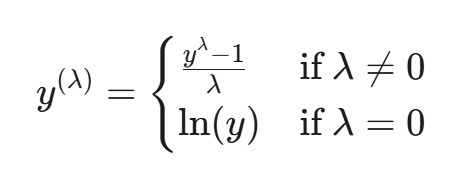

In [ ]:
# using the boxcox function
price_transf, lambda_value = boxcox(diamonds['price']) # log transformation
price_transf
 

array([4.79712763, 4.79712763, 4.79920594, ..., 6.14717692, 6.14717692,
       6.14717692])

In [ ]:
lambda_value

-0.06699030544539092

lambda_value is very close to 0. It means that the transformation that makes our data most normal is one that is very similar to the natural logarithm.

The histogram of the price now looks like the following. This is good because when creating a linear regression, it's ideal for the data to be as normally distributed as possible. This is a lot closer to a normal distribution than the previous histogram.

<Axes: ylabel='Count'>

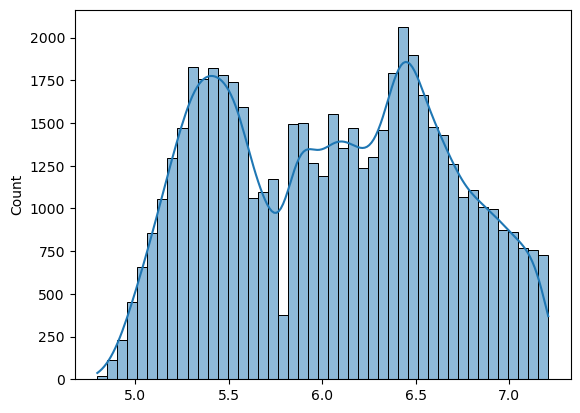

In [ ]:
sns.histplot(price_transf, kde = True)

In [ ]:
X_train, X_test, y_train_transf, y_test_transf = train_test_split(X_norm, price_transf, test_size=0.2, random_state = 42)

In [ ]:
ridge_regr_model = Ridge(alpha=1)
ridge_regr_model.fit(X_train, y_train_transf)

y_predicted = ridge_regr_model.predict(X_test)
y_estimated = ridge_regr_model.predict(X_train)

print('Train r2 =', ridge_regr_model.score(X_train, y_train_transf))
print('Test r2 =', ridge_regr_model.score(X_test, y_test_transf))

print('MAE_test =', mean_absolute_error(y_test_transf, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test_transf, y_predicted))

print('MAE_train =', mean_absolute_error(y_train_transf, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train_transf, y_estimated))

print(ridge_regr_model.coef_)

Train r2 = 0.9666088904119794
Test r2 = 0.9710078120651694
MAE_test = 0.07060742708612741
RMSE_test = 0.10247991625819891
MAE_train = 0.07051256772453764
RMSE_train = 0.10979521575306525
[-1.84353434  1.0974417   0.28062695  7.3984898   1.14392434  1.10438532
 -0.02712534 -0.01975894 -0.03777537 -0.08837814 -0.03475386 -0.05297419
 -0.09539673 -0.15586826 -0.23089113 -0.31010311 -0.05268777 -0.09373162
 -0.16405177 -0.20269612 -0.28480594 -0.38092785 -0.63572073]


In [ ]:
cross_val_results(X_norm, price_transf, model = Ridge(alpha=1), cv=5, scoring = 'r2')

Scores: [0.92804531 0.92011278 0.96395757 0.73717415 0.87878798]
Mean: 0.8856155583089711
Std: 0.07900541785495034


## Inverse Cox-Box function

To get the predicted values, we need to remember that these predictions will be in the transformed scale (we applied a log transformation). To interpret these predicitons in the original scale of the 'price' variable we will need to reverse the BoxCox transformation. This will give us the predicted price values in the original scale.

In [65]:
from scipy.special import inv_boxcox

In [66]:
predictions_original_scale = inv_boxcox(y_predicted, lambda_value)

In [67]:
predictions_original_scale

array([ 574.10816945, 2278.52314598, 1317.9249582 , ...,  741.47623102,
       9201.90455928, 2551.64548799])

# Non-linear regression models

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state = 42)

## GLR(Generalized Linear Regression) - no linear relationships

In [68]:
from sklearn.linear_model import TweedieRegressor

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.TweedieRegressor.html

"The power determines the underlying target distribution".
- power = 0: Normal distribution. Specific estimators such as Ridge, ElasticNet are generally more appropriate in this case.

- power = 1: Poisson distribution. PoissonRegressor is exposed for convenience. However, it is strictly equivalent to TweedieRegressor(power=1, link='log').

- power = 2: Gamma distribution. GammaRegressor is exposed for convenience. However, it is strictly equivalent to TweedieRegressor(power=2, link='log').

- power = 3: Inverse Gaussian distribution.

The link function transforms the relationship between the predictors and the target.

In [69]:
X = diamonds_dummies.drop(columns = ['cut', 'color', 'clarity', 'price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [70]:
# for monetary targets the most appropriate is Gamma distribution

tr = TweedieRegressor(power=2, link='log')
tr.fit(X_train, y_train)

y_predicted = tr.predict(X_test)
y_estimated = tr.predict(X_train)

print('Train r2 =', tr.score(X_train, y_train))
print('Test r2 =', tr.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(tr.coef_)

Train r2 = 0.8126898525248387
Test r2 = 0.8304683940715403
MAE_test = 1078.6587002564793
RMSE_test = 1957.9888823173578
MAE_train = 71963.74204415169
RMSE_train = 14711723.0044769
[ 0.12499681  0.00979517  0.01050303  0.23859125  0.23754677  0.14515302
  0.00532268 -0.00143219 -0.00317892 -0.0022924  -0.00317336  0.00764721
  0.00778598 -0.0022254  -0.00843069 -0.00822885  0.00421887  0.00702721
  0.00490159  0.00515089 -0.01165386 -0.00847713 -0.00512138]


In [79]:
cross_val_results(X, y, model = TweedieRegressor(power=2, link='log', max_iter=200), cv=kf, scoring = 'r2')

Scores: [ 6.50211178e-01 -6.65817176e-02 -3.08582444e+06 -7.49966195e+00
 -7.63081743e+02]
Mean: -617318.8873383176
Std: 1234252.810962306


## Polynomial Regression

https://machinewithdata.com/2018/06/29/types-of-regression-2/

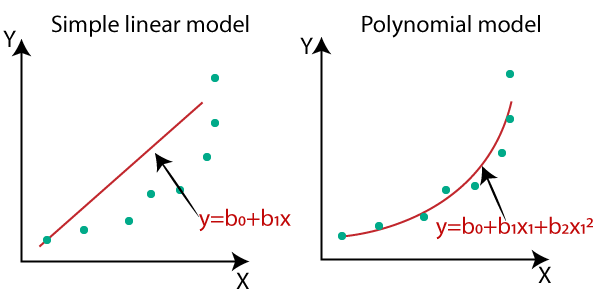

https://www.analyticsvidhya.com/blog/2021/10/understanding-polynomial-regression-model/

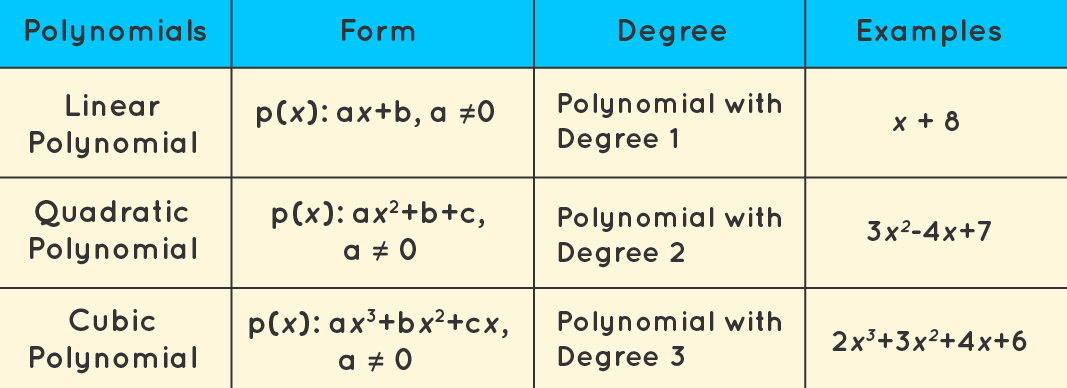

In [72]:
from sklearn.preprocessing import PolynomialFeatures

In [73]:
poly = PolynomialFeatures(degree=2, include_bias=False)

**PolynomialFeatures(degree=2, include_bias=False)** expands the feature set so a linear model can capture non-linear relationships.

- **degree=2**  
  Adds squared terms (e.g. \(x^2\)) and interaction terms (e.g. \(x_1 x_2\)) alongside the original features.

- **include_bias=False**  
  Prevents adding a constant column of 1s, since most models already include an intercept term.

This allows the model to represent curvature and feature interactions while avoiding a duplicate intercept.


Note: susceptible to overfitting, and will struggle with higher degrees!

In [74]:
poly_features = poly.fit_transform(X_norm)
poly_features

array([[0.00623701, 0.51388889, 0.23076923, ..., 1.        , 0.        ,
        0.        ],
       [0.002079  , 0.46666667, 0.34615385, ..., 0.        , 0.        ,
        0.        ],
       [0.00623701, 0.38611111, 0.42307692, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.1039501 , 0.55      , 0.32692308, ..., 0.        , 0.        ,
        0.        ],
       [0.13721414, 0.5       , 0.28846154, ..., 1.        , 0.        ,
        0.        ],
       [0.11434511, 0.53333333, 0.23076923, ..., 1.        , 0.        ,
        0.        ]])

In [75]:
poly_features.shape

(53940, 299)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, price_transf, test_size = 0.2, random_state = 42)

In [77]:
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train, y_train)

y_predicted = poly_reg_model.predict(X_test)
y_estimated = poly_reg_model.predict(X_train)

print('Train r2 =', poly_reg_model.score(X_train, y_train))
print('Test r2 =', poly_reg_model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(poly_reg_model.coef_)

#try Ridge

Train r2 = 0.9871702588592437
Test r2 = 0.9862489636521323
MAE_test = 0.05207720980957171
RMSE_test = 0.07057745296423433
MAE_train = 0.051716934779907145
RMSE_train = 0.06805764826599105
[ 1.06502187e+01  4.09844567e+00 -4.91933530e-01  2.99276021e+01
 -2.91735477e+01 -6.68363328e+01  2.24348968e-01 -1.27991692e-01
  2.30657901e-01  2.98972018e-01 -2.30358903e-01 -2.00352835e-01
 -3.35081944e-01 -4.34713011e-01 -3.63010645e-01 -3.10860997e-01
 -1.98406636e-02 -2.80652583e-01 -7.53233984e-01 -3.28924289e-01
 -4.85465780e-01 -6.03270684e-01 -4.52266521e-01  5.04248454e+00
  2.72636721e+00 -8.11136489e-01 -1.07583832e+01  1.10624276e+02
 -1.31343690e+02  7.83480255e-01 -1.84540723e-01  6.73675062e-01
  1.43100903e+00  1.13139623e-03  7.22309740e-01  4.95944093e-02
 -1.40245801e-01  4.37901719e-01  4.59675706e-01  7.02360561e-01
  7.68446118e-02  8.82936616e-04  6.44540773e-01  1.42445181e-01
  1.91948826e-02  7.19854196e-01 -5.18605029e-01  1.75006017e+00
 -2.64498575e+00 -4.07855147e+01

Polynomial regression has many coefficients because it **expands the original feature set** into additional terms.

- Original features are kept (e.g. \(x_1, x_2\))
- **Squared terms** are added (e.g. \(x_1^2\))
- **Interaction terms** are added (e.g. \(x_1 x_2\))

As the number of original features increases, the number of generated polynomial features grows **very quickly**. With many predictors (especially dummy variables), this leads to a large number of coefficients.

In practice, this increases model complexity and variance, which is why polynomial regression is usually combined with **feature scaling** and **regularisation** (e.g. Ridge regression).


In [80]:
cross_val_results(poly_features, price_transf, model = LinearRegression(), cv=kf, scoring = 'r2')

Scores: [ 0.96196406 -1.26572201  0.70369787  0.77003501 -9.45291107]
Mean: -1.6565872265219597
Std: 3.981248374632717


## Logistic Regression

Is a type of regression used for classification. We will learn about it in session 3.8